In [46]:
%reload_ext autoreload
%autoreload 2

import os
import sys
from tqdm import tqdm

import jax
from jax import jit
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from functools import partial

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

[gpu(id=0)]


In [2]:
sys.path.append("../..")
from models.np_model import NPModel
from simulations.wrapper import simulator_for_model
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/fit_np_to_np/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


## 1. Generate counts

### 1.1 everything

In [4]:
S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
        Sps_dsk = 1.3, zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"data/truth-{run_name}.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"data/counts-{run_name}.npy", counts)

S1.500Sps0.010


/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


S0.750Sps0.750
S0.010Sps1.500


### 1.2 bare: just gce

In [66]:
S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
        Sps_dsk = 0., zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"truth-{run_name}-bare.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"counts-{run_name}-bare.npy", counts)

S5.000Sps0.010
S2.500Sps2.500
S0.010Sps5.000


### 1.3 np_np (full model)

In [41]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.3, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"truth-{run_name}-npnp.p", 'wb'))

counts = simulator_for_model(npmodel, var_dict)
np.save(f"counts-{run_name}-npnp.npy", counts)

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


In [57]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.0, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 2.0, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"data/truth-npnp-alt.p", 'wb'))

for i in range(4):
    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"data/counts-npnp-alt-{i}.npy", counts)

### 1.4 view

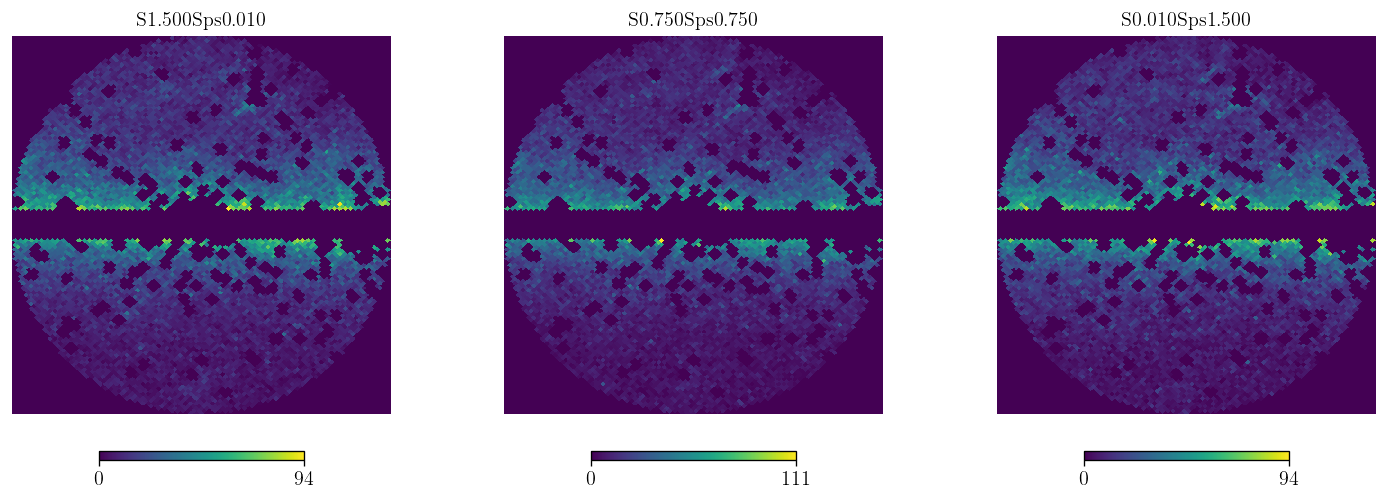

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
ll_arr_arr = []
for i, (S_gce, Sps_gce) in enumerate(S_Sps_arr):
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"

    counts = jnp.array(jnp.load(f"data/counts-{run_name}.npy"), dtype=np.int32)

    plt.sca(axs[i])
    hp.cartview(counts, lonra=[-25, 25], latra=[-25, 25], hold=True, title=run_name)

## 2. Likelihood

In [42]:
#@partial(jit, static_argnums=(0,2))
def ll(m, vd, data, S_gce, Sps_gce):

    if not m.non_poissonian:
        raise NotImplementedError

    theta_pib = vd['theta_pib']
    theta_ics = vd['theta_pib']
    temp_pib = jnp.sum(theta_pib[:, None] * m.pib, 0)
    temp_ics = jnp.sum(theta_ics[:, None] * m.ics, 0)

    #S_gce = vd['S_gce']
    temps = [m.temp_iso, m.temp_bub, m.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)

    for temp, temp_label in zip(temps, temp_labels):
        S_temp = vd["S_{}".format(temp_label)]
        if temp_label in ["pib"]:
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(m.Ylm_temps)):
                Alm = vd["Alm_{}".format(ii)]
                temp_pib_mod += Alm * m.Ylm_temps[ii]
            temp_pib_mod = (1. + temp_pib_mod) * temp
            A_temp = S_temp / jnp.mean(temp_pib_mod[~m.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~m.normalization_mask])
            mu += A_temp * temp     
                                        
    if m.vary_gamma:
        gamma_ps = vd["gamma_ps"]
        gamma_poiss = vd["gamma_poiss"]
    else:
        gamma_ps = 1.2
        gamma_poiss = 1.2
    temp_gce_nfw_ps = m.nfw_template.get_NFW2_template(gamma=gamma_ps)
    temp_gce_nfw_poiss = m.nfw_template.get_NFW2_template(gamma=gamma_poiss)

    if m.vary_disk:
        zs = vd["zs"]
        C = vd["C"]
        temp_dsk = m.disk_template.get_template(zs=zs, C=C)
    else:
        temp_dsk = m.temp_dsk
            
    if m.bulge_hybrid:
        f_bulge_ps = vd["f_bulge_ps"]
        f_bulge_poiss = vd["f_bulge_poiss"]
        theta_bulge_poiss = vd["theta_bulge_poiss"]
        temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * m.bulge_templates, 0)
    else:
        f_bulge_ps = 0.
        f_bulge_poiss = vd["f_bulge_poiss"]
        temp_bulge = m.bulge_templates[0]

    A_gce_nfw = S_gce / jnp.mean(temp_gce_nfw_poiss[~m.normalization_mask])
    A_gce_bulge = S_gce / jnp.mean(temp_bulge[~m.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge

    A_gce = S_gce / jnp.mean(temp_gce_poiss[~m.normalization_mask])
    mu += A_gce * temp_gce_poiss

    theta_bulge_ps = vd["theta_bulge_ps"]
    temp_bulge = jnp.sum(theta_bulge_ps[:, None] * m.bulge_templates, 0)

    A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~m.normalization_mask])
    A_gce_bulge = 1 / jnp.mean(temp_bulge[~m.normalization_mask])

    temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge
    npt_compressed = jnp.array([temp_gce_ps, temp_dsk])
    theta = []    
    for ips, ps in enumerate(["gce", "dsk"]):
        Sps = vd["Sps_{}".format(ps)]
        if ps == 'gce':
            Sps = Sps_gce
        n1 = vd["n1_{}".format(ps)]
        n2 = vd["n2_{}".format(ps)]
        n3 = vd["n3_{}".format(ps)]
        sb1 = vd["sb1_{}".format(ps)]
        lambda_s = vd["lambdas_{}".format(ps)]
        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(0., 2, 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps / jnp.mean(npt_compressed[ips][~m.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)
    
    mu_masked = mu[~m.mask_roi]
    npt_compressed_masked = npt_compressed[:, ~m.mask_roi]
    data_masked = data[~m.mask_roi]
    ll_arr = log_like_np(theta, mu_masked, npt_compressed_masked, data_masked, m.f_ary, m.df_rho_div_f_ary, m.k_max, len(mu_masked))
    return jnp.sum(ll_arr)

In [6]:
S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
ll_arr_arr = []
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    counts = jnp.array(jnp.load(f"data/counts-{run_name}.npy"), dtype=np.int32)
    var_dict = pickle.load(open(f"data/truth-{run_name}.p", 'rb'))

    S_arr = np.geomspace(1e-2, 3, 30)
    Sps_arr = np.geomspace(1e-2, 3, 30)
    ll_arr = np.zeros((len(S_arr), len(Sps_arr)))
    for i_S, S in enumerate(tqdm(S_arr)):
        for i_Sps, Sps in enumerate(Sps_arr):
            ll_arr[i_S, i_Sps] = ll(npmodel, var_dict, counts, S, Sps)
    ll_arr_arr.append(ll_arr)

S1.500Sps0.010


100%|██████████| 30/30 [00:49<00:00,  1.64s/it]


S0.750Sps0.750


100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


S0.010Sps1.500


100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


/tmp/ipykernel_2925219/2578599796.py:6: UserWarning: The following kwargs were not used by contour: 'aspect'
  ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)


Text(0.5, 0.98, 'Likelihood (full model, truth values for variables not shown)')

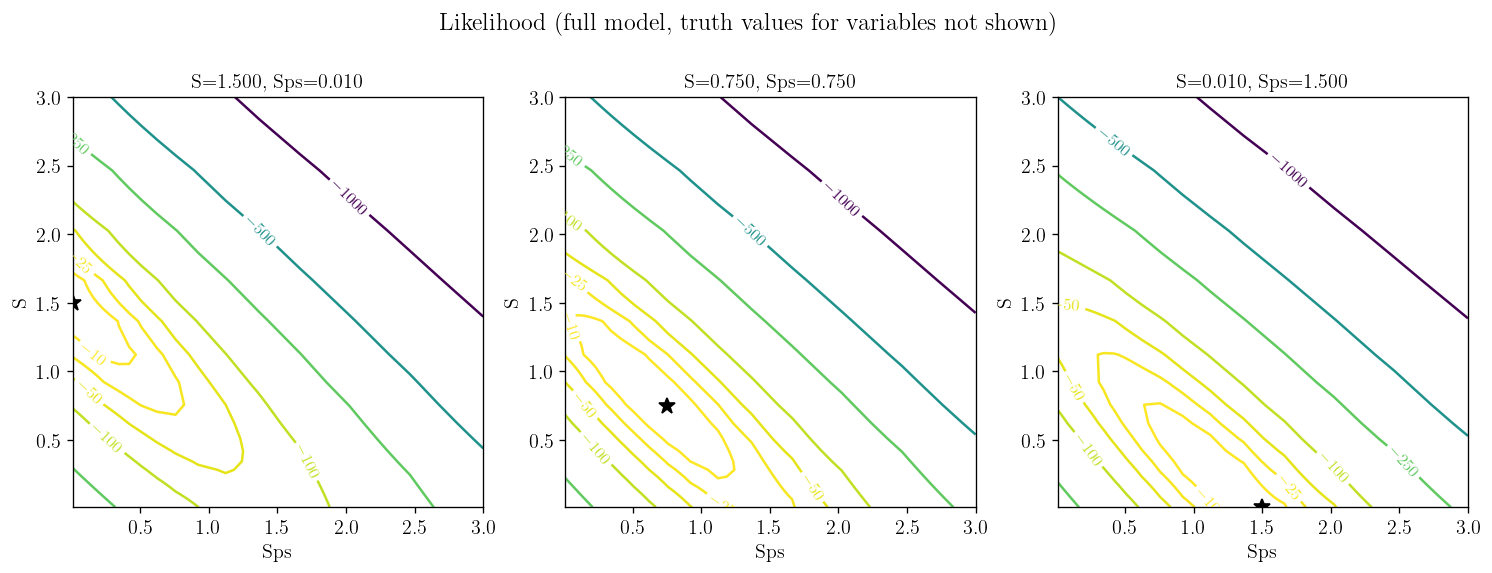

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, ll_arr in enumerate(ll_arr_arr):
    S_gce, Sps_gce = S_Sps_arr[i]
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    # show contour labels
    ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)
    axs[i].clabel(ct, inline=True, fontsize=10)
    axs[i].set(aspect=1)
    axs[i].set(xlabel="Sps", ylabel="S", title=f'S={S_gce:.3f}, Sps={Sps_gce:.3f}')
    axs[i].plot(Sps_gce, S_gce, '*', color='k', ms=10)
fig.suptitle('Likelihood (full model, truth values for variables not shown)')

In [53]:
#@partial(jit, static_argnums=(0,2))
def ll(m, vd, data):

    if not m.non_poissonian:
        raise NotImplementedError

    theta_pib = vd['theta_pib']
    theta_ics = vd['theta_pib']
    temp_pib = jnp.sum(theta_pib[:, None] * m.pib, 0)
    temp_ics = jnp.sum(theta_ics[:, None] * m.ics, 0)

    #S_gce = vd['S_gce']
    temps = [m.temp_iso, m.temp_bub, m.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)

    for temp, temp_label in zip(temps, temp_labels):
        S_temp = vd["S_{}".format(temp_label)]
        if temp_label in ["pib"]:
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(m.Ylm_temps)):
                Alm = vd["Alm_{}".format(ii)]
                temp_pib_mod += Alm * m.Ylm_temps[ii]
            temp_pib_mod = (1. + temp_pib_mod) * temp
            A_temp = S_temp / jnp.mean(temp_pib_mod[~m.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~m.normalization_mask])
            mu += A_temp * temp     
                                        
    if m.vary_gamma:
        gamma_ps = vd["gamma_ps"]
        gamma_poiss = vd["gamma_poiss"]
    else:
        gamma_ps = 1.2
        gamma_poiss = 1.2
    temp_gce_nfw_ps = m.nfw_template.get_NFW2_template(gamma=gamma_ps)
    temp_gce_nfw_poiss = m.nfw_template.get_NFW2_template(gamma=gamma_poiss)

    if m.vary_disk:
        zs = vd["zs"]
        C = vd["C"]
        temp_dsk = m.disk_template.get_template(zs=zs, C=C)
    else:
        temp_dsk = m.temp_dsk
            
    if m.bulge_hybrid:
        f_bulge_ps = vd["f_bulge_ps"]
        f_bulge_poiss = vd["f_bulge_poiss"]
        theta_bulge_poiss = vd["theta_bulge_poiss"]
        temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * m.bulge_templates, 0)
    else:
        f_bulge_ps = 0.
        f_bulge_poiss = vd["f_bulge_poiss"]
        temp_bulge = m.bulge_templates[0]

    A_gce_nfw = vd['S_gce'] / jnp.mean(temp_gce_nfw_poiss[~m.normalization_mask])
    A_gce_bulge = vd['S_gce'] / jnp.mean(temp_bulge[~m.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge

    A_gce = vd['S_gce'] / jnp.mean(temp_gce_poiss[~m.normalization_mask])
    mu += A_gce * temp_gce_poiss

    theta_bulge_ps = vd["theta_bulge_ps"]
    temp_bulge = jnp.sum(theta_bulge_ps[:, None] * m.bulge_templates, 0)

    A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~m.normalization_mask])
    A_gce_bulge = 1 / jnp.mean(temp_bulge[~m.normalization_mask])

    temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge
    npt_compressed = jnp.array([temp_gce_ps, temp_dsk])
    theta = []    
    for ips, ps in enumerate(["gce", "dsk"]):
        Sps = vd["Sps_{}".format(ps)]
        n1 = vd["n1_{}".format(ps)]
        n2 = vd["n2_{}".format(ps)]
        n3 = vd["n3_{}".format(ps)]
        sb1 = vd["sb1_{}".format(ps)]
        lambda_s = vd["lambdas_{}".format(ps)]
        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(0., 2, 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps / jnp.mean(npt_compressed[ips][~m.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)
    
    mu_masked = mu[~m.mask_roi]
    npt_compressed_masked = npt_compressed[:, ~m.mask_roi]
    data_masked = data[~m.mask_roi]
    ll_arr = log_like_np(theta, mu_masked, npt_compressed_masked, data_masked, m.f_ary, m.df_rho_div_f_ary, m.k_max, len(mu_masked))
    return jnp.sum(ll_arr)

In [63]:
ll_arr_arr = []

for i_counts in range(4):
    counts = jnp.array(jnp.load(f"data/counts-npnp-alt-{i_counts}.npy"), dtype=np.int32)
    var_dict = pickle.load(open(f"data/truth-npnp-alt.p", 'rb'))

    k1 = 'Sps_dsk'
    k2 = 'S_ics'

    Sk1_arr = np.linspace(1e-2, 4, 30)
    Sk2_arr = np.linspace(1e-2, 10, 31)
    ll_arr = np.zeros((len(Sk1_arr), len(Sk2_arr)))
    for i_1, Sk1 in enumerate(tqdm(Sk1_arr)):
        for i_2, Sk2 in enumerate(Sk2_arr):
            vd_in = var_dict.copy()
            vd_in.update({k1: Sk1, k2: Sk2})
            ll_arr[i_1, i_2] = ll(npmodel, vd_in, counts)
    ll_arr_arr.append(ll_arr)

100%|██████████| 30/30 [00:38<00:00,  1.28s/it]


/tmp/ipykernel_2925219/2777918086.py:8: UserWarning: The following kwargs were not used by contour: 'aspect'
  ct = ax.contour((Sk2_arr), (Sk1_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)


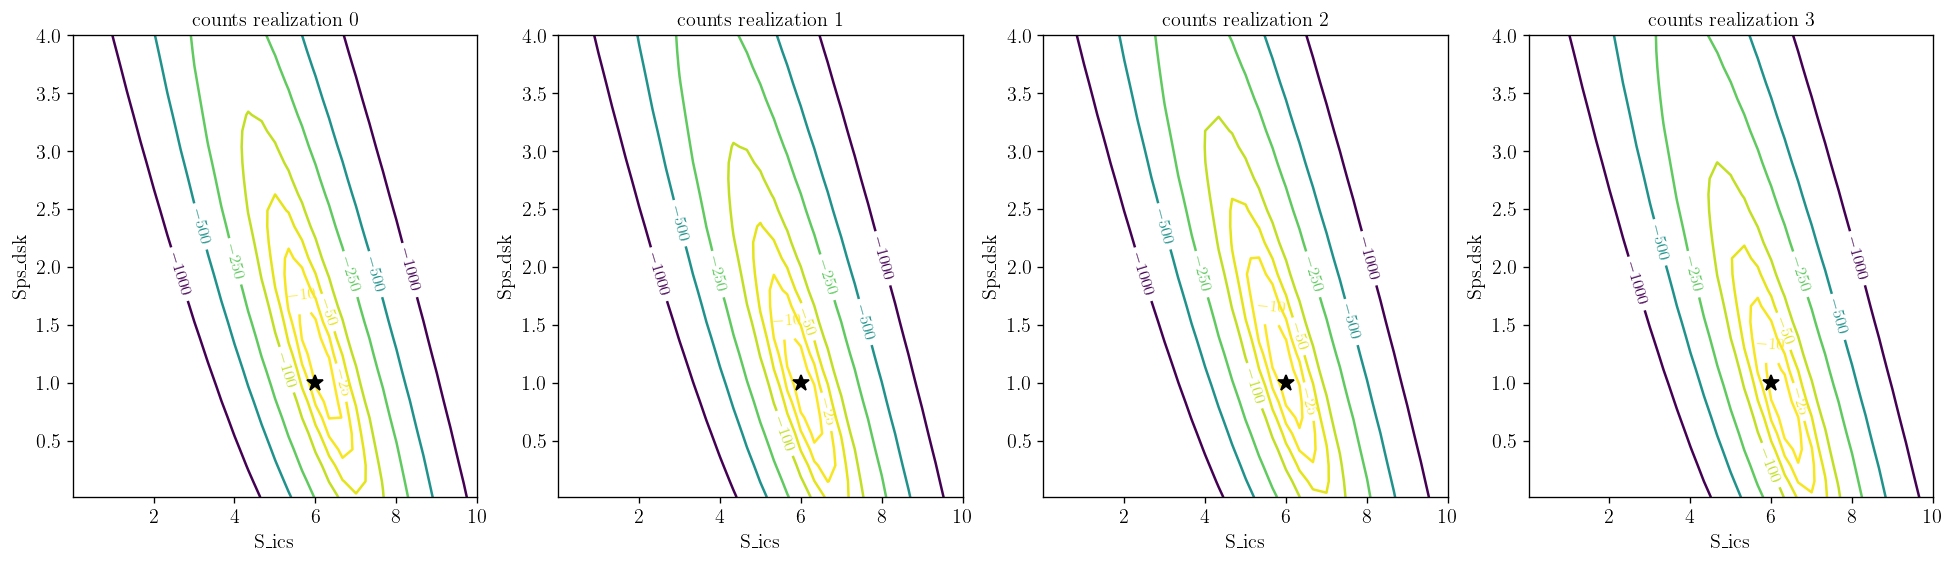

In [64]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# 2 is x, 1 is y

for i in range(4):
    ax = axs[i]
    ll_arr = ll_arr_arr[i]
    ct = ax.contour((Sk2_arr), (Sk1_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)
    ax.clabel(ct, inline=True, fontsize=10)
    #ax.set(aspect=1)
    ax.set(xlabel=k2, ylabel=k1, title=f'counts realization {i}')
    ax.plot(var_dict[k2], var_dict[k1], '*', color='k', ms=10);

### comapre with posterior

In [ ]:
from utils.multi_corner import multi_corner

In [38]:
save_dir = "../../outputs/np_np"
samples_fn_list = [f for f in os.listdir(save_dir) if f.startswith("hmc_samples") and not f.endswith("noNT.p")]
n_run = len(samples_fn_list)
truth_dict = pickle.load(open(f"{save_dir}/truth.p", 'rb'))

In [39]:
svi_samples_list = []
mean_arr = []
for samples_fn in tqdm(samples_fn_list):
    svi_samples_list.append(pickle.load(open(f'{save_dir}/{samples_fn}', 'rb')))
    mean_arr.append(np.mean(svi_samples_list[-1]['Sps_gce']))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 84.36it/s]


In [40]:
samples_dict = {
    f'{i}' : s
    for i, s in enumerate(svi_samples_list)
}
colors_dict = {
    f'{i}' : cms['viridis']( (mean_arr[i]-np.min(mean_arr))/(np.max(mean_arr)-np.min(mean_arr)) )
    for i, s in enumerate(svi_samples_list)
}
labels_dict = None
plot_var_names = [
    'S_ics', 'Sps_gce', 'Sps_dsk',
]
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    point_est=truth_dict,
    hist_bin_factor=1, save_fn='hmc-NT.png'
)